In [7]:
import geopandas as gpd
import pandas as pd

blocks_gdf = pd.read_pickle('./../data/saint_petersburg/blocks.pickle')[['geometry']]
blocks_gdf.head()

,geometry
0,"POLYGON ((349424.859 6631180.891, 349424.751 6..."
1,"POLYGON ((352083.617 6633950.146, 352240.448 6..."
2,"POLYGON ((346700.642 6618453.176, 346681.107 6..."
3,"POLYGON ((347043.363 6618261.219, 347042.608 6..."
4,"POLYGON ((354879.039 6618859.116, 354845.405 6..."


In [8]:
functional_zones_gdf = gpd.read_file('functional_zones.geojson').to_crs(blocks_gdf.crs)
functional_zones_gdf.head()

,functional_zone,geometry
0,Т1Ж2-2,"MULTIPOLYGON (((349202.695 6660862.796, 349199..."
1,Т1Ж2-2,"MULTIPOLYGON (((345558.116 6666406.372, 345528..."
2,Т1Ж2-2,"MULTIPOLYGON (((347805.242 6663237.649, 347790..."
3,Т1Ж2-2,"MULTIPOLYGON (((346292.257 6667294.593, 346266..."
4,Т1Ж2-2,"MULTIPOLYGON (((350166.384 6660332.141, 350186..."


## Objects assignment

In [9]:
from blocksnet.blocks.assignment import assign_objects

objects_gdf = assign_objects(blocks_gdf, functional_zones_gdf.rename(columns={'functional_zone': 'name'}))
objects_gdf.head()

,geometry,Т1Ж2-2,Т2Ж1,Т3Ж1,Т3Ж2,ТУ,ТИ2,ТИ3,ТД1-2,ТД2,...,ТР1,ТР4,ТР5-1,ТР5-2,ТК1,ТК2,ТС2,ТК3,name,share
0,"POLYGON ((349424.859 6631180.891, 349424.751 6...",0.000000,0.0,0.0,0.0,1.000000,0.0,0.000000,0.000000,0.0,...,0.0,0.0,0.0,0.000000,0.0,0.0,0.0,0.0,ТУ,1.000000
1,"POLYGON ((352083.617 6633950.146, 352240.448 6...",0.000000,0.0,0.0,0.0,0.130075,0.0,0.270998,0.099000,0.0,...,0.0,0.0,0.0,0.079912,0.0,0.0,0.0,0.0,ТС1,0.417018
2,"POLYGON ((346700.642 6618453.176, 346681.107 6...",1.000000,0.0,0.0,0.0,0.000000,0.0,0.000000,0.000000,0.0,...,0.0,0.0,0.0,0.000000,0.0,0.0,0.0,0.0,Т1Ж2-2,1.000000
3,"POLYGON ((347043.363 6618261.219, 347042.608 6...",0.729125,0.0,0.0,0.0,0.000000,0.0,0.000000,0.000000,0.0,...,0.0,0.0,0.0,0.000000,0.0,0.0,0.0,0.0,Т1Ж2-2,0.729125
4,"POLYGON ((354879.039 6618859.116, 354845.405 6...",0.268573,0.0,0.0,0.0,0.144935,0.0,0.000000,0.179297,0.0,...,0.0,0.0,0.0,0.000000,0.0,0.0,0.0,0.0,ТС1,0.399984


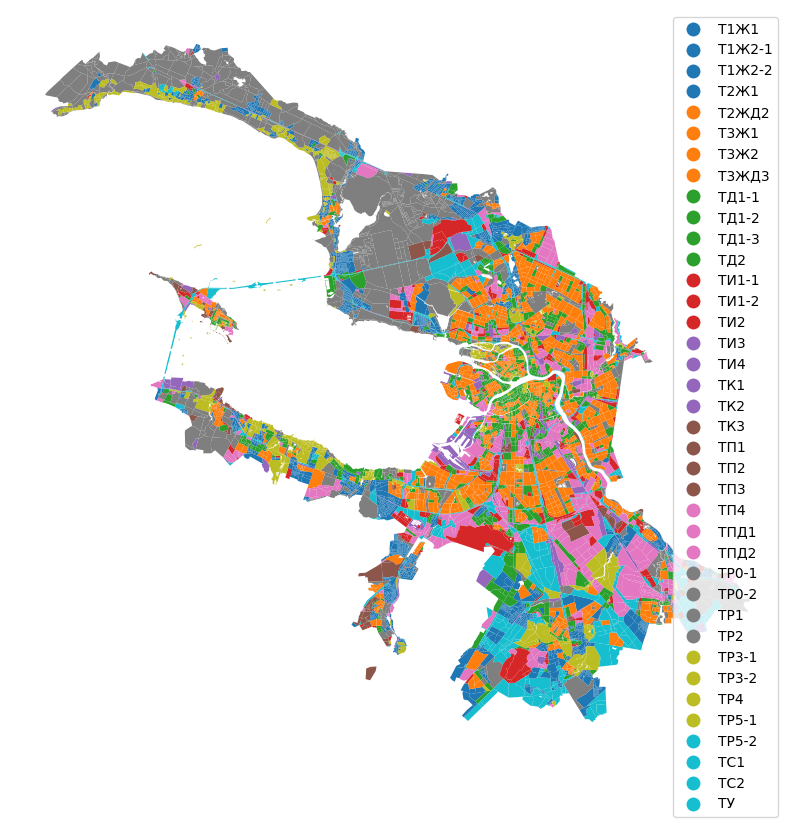

In [10]:
objects_gdf.plot('name', legend=True, figsize=(10,10)).set_axis_off()

## Land use assignment

In [11]:
from blocksnet.enums import LandUse

rules = {
    "Т3Ж1": LandUse.RESIDENTIAL,
    "ТР0-2": LandUse.RECREATION,
    "Т3Ж2": LandUse.RESIDENTIAL,
    "Т1Ж2-1": LandUse.RESIDENTIAL,
    "Т2ЖД2": LandUse.RESIDENTIAL,
    "ТД1-3": LandUse.BUSINESS,
    "ТД2": LandUse.BUSINESS,
    "ТД3": LandUse.BUSINESS,
    "ТУ": LandUse.TRANSPORT,
    "ТИ4": LandUse.TRANSPORT,
    "ТД1-1": LandUse.RESIDENTIAL,
    "ТД1-2": LandUse.RESIDENTIAL,
    "ТПД1": LandUse.INDUSTRIAL,
    "ТПД2": LandUse.INDUSTRIAL,
    "ТИ1-1": LandUse.TRANSPORT,
    "Т3ЖД3": LandUse.RESIDENTIAL,
    "ТК1": LandUse.SPECIAL,
    "ТР2": LandUse.RECREATION,
    "ТИ2": LandUse.TRANSPORT,
    "ТР5-2": LandUse.RECREATION,
    "Т1Ж2-2": LandUse.RESIDENTIAL,
    "ТР4": LandUse.RECREATION,
    "ТР5-1": LandUse.RECREATION,
    "Т2Ж1": LandUse.RESIDENTIAL,
    "ТИ3": LandUse.TRANSPORT,
    "Т1Ж1": LandUse.RESIDENTIAL,
    "ТИ1-2": LandUse.TRANSPORT,
    "ТР3-2": LandUse.RECREATION,
    "ТР0-1": LandUse.RECREATION,
    "ТП2": LandUse.INDUSTRIAL,
    "ТК3": LandUse.SPECIAL,
    "ТР1": LandUse.RECREATION,
    "ТР3-1": LandUse.RECREATION,
    "ТС1": LandUse.AGRICULTURE,
    "ТК2": LandUse.SPECIAL,
    "ТП1": LandUse.INDUSTRIAL,
    "ТП3": LandUse.INDUSTRIAL,
    "ТП4": LandUse.INDUSTRIAL,
    "ТС2": LandUse.SPECIAL,
}

In [19]:
import math

math.ceil(1/1000*16)

1

In [12]:
from blocksnet.blocks.assignment import assign_land_use

land_use_gdf = assign_land_use(blocks_gdf, functional_zones_gdf, rules)
land_use_gdf.head()

,geometry,residential,business,recreation,industrial,transport,special,agriculture,land_use,share
0,"POLYGON ((349424.859 6631180.891, 349424.751 6...",0.000000,0.0,0.000000,0.0,1.000000,0.0,0.000000,LandUse.TRANSPORT,1.000000
1,"POLYGON ((352083.617 6633950.146, 352240.448 6...",0.099000,0.0,0.079912,0.0,0.401072,0.0,0.417018,LandUse.AGRICULTURE,0.417018
2,"POLYGON ((346700.642 6618453.176, 346681.107 6...",1.000000,0.0,0.000000,0.0,0.000000,0.0,0.000000,LandUse.RESIDENTIAL,1.000000
3,"POLYGON ((347043.363 6618261.219, 347042.608 6...",0.729125,0.0,0.270875,0.0,0.000000,0.0,0.000000,LandUse.RESIDENTIAL,0.729125
4,"POLYGON ((354879.039 6618859.116, 354845.405 6...",0.454375,0.0,0.000000,0.0,0.144935,0.0,0.399984,LandUse.RESIDENTIAL,0.454375


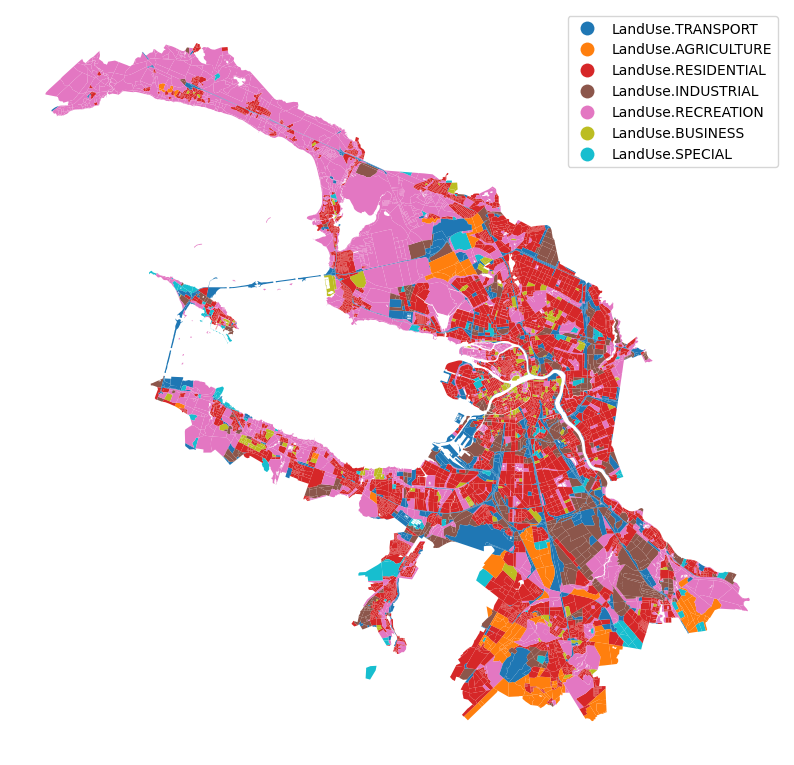

In [13]:
land_use_gdf.plot(column='land_use', legend=True, figsize=(10,10)).set_axis_off()

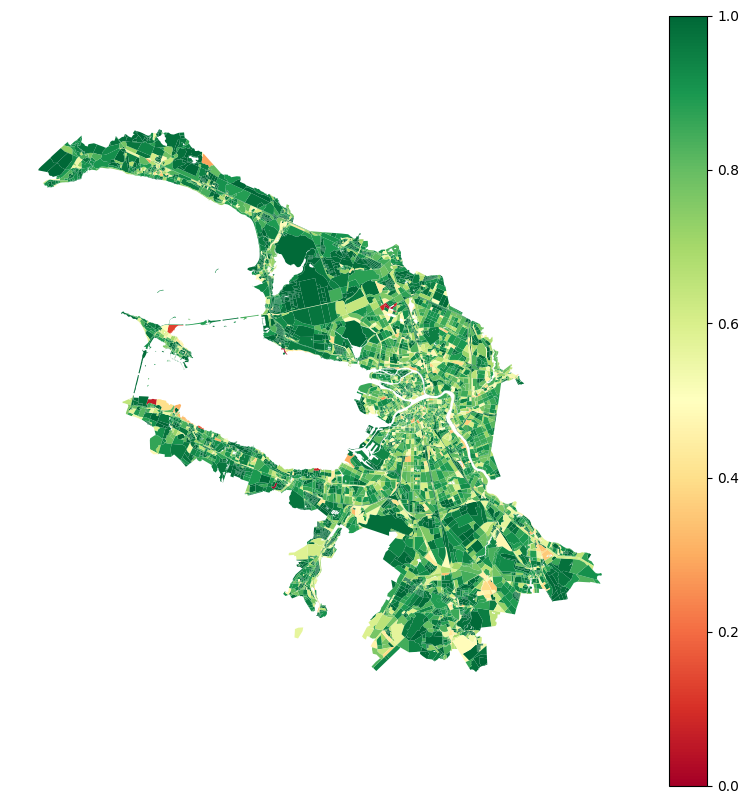

In [14]:
land_use_gdf.plot(column='share', cmap='RdYlGn', legend=True, vmin=0, vmax=1, figsize=(10,10)).set_axis_off()